### 1.对比Fu et al. 论文中的数值结果。
### 2.执行与原来方法进行对比。
### 3.执行原方法，reduce and expansion 模型的对比。
### 4.执行干湿模态对比，采用reduce model and 实验数据进行对比
### 5.执行beta = 0 ,0.25 ,0.5, 0.75,1  + 10节点惯性，无量纲刚度比较
### 6.对比Fu et al.论文中的数值结果，点p1的结果，频率0.1-2.0 , 计算波长等
### 7.对比S4R，S4，S4R5三个单元的区别,结果无区别。

In [1]:
#import packages
import time
import numpy as np
import capytaine as cpt
import scipy
from capytaine.io.mesh_writers import write_STL
import matplotlib.pyplot as plt
from scipy.linalg import block_diag
from scipy.linalg import eigh
import vtk
import logging
import xarray as xr
from capytaine.io.xarray import merge_complex_values
from capytaine.post_pro import rao
logging.basicConfig(level=logging.INFO, format='%(levelname)-8s: %(message)s')
# user defined functions
import DM_ShowNodes as DMshow
import DM_Reading as dm_r
import DM_Assemble as DM_A
import SEREP as SEREP
from DM_Verify import process_exp_data

In [ ]:
# Show nodes and node message
file_path = "E:\phd\Code\DM-FEM2D\Fem_inp\Job-1_largemesh.inp"
label_interval = 1
node = DMshow.plot_fea_model(file_path, label_interval)
#node_ids = [41, 39, 37, 35, 33, 31, 29, 27, 25, 23]

In [3]:
# 原方法
def calculate_displacement(N, file_path, dataset, nodes):
    """
    Calculate the displacement for a given system of order method.

    Parameters:
    N (int): The number of nodes in the system.
    file_path (str): Path to the stiffness matrix file.
    dataset (DataFrame): A pandas DataFrame containing the necessary data.
    nodes (array): Array of node positions.

    Returns:
    ndarray: The displacement array.
    """

    # Extract data from the dataset
    added_mass = dataset['added_mass'][0].values
    radiation_damping = dataset['radiation_damping'][0].values
    inertia_matrix = dataset['inertia_matrix'].values
    hydrostatic_stiffness = dataset['hydrostatic_stiffness'].values
    F_w = dataset['Froude_Krylov_force'][0].values + dataset['diffraction_force'][0].values

    # Construct the combined matrices
    M = added_mass + inertia_matrix  # Total mass
    C = radiation_damping  # Damping
    K = hydrostatic_stiffness  # Stiffness

    # Insert matrices into the system
    mass = DM_A.insert_matrix(N, M, nodes)
    damping = DM_A.insert_matrix(N, C, nodes)
    hy_stiffness = DM_A.insert_matrix(N, K, nodes)

    # Assemble the stiffness matrix
    stiffness = dm_r.get_stiffness_matrix(file_path) + hy_stiffness

    # Assemble the force matrix
    K_F_w = DM_A.extend_force_matrix(F_w, nodes, N)
    omega = dataset.omega.values
    # Solve in the frequency domain
    X = DM_A.solve_frequency_domain(mass, damping, stiffness, K_F_w, omega)

    return X

In [4]:
# 扩展方法，expansion
def perform_expansion_and_solve(k, M, SlaveDofs, dataset, master_nodes,MasterDofs):
    """
    Perform expansion process and solve for global displacement.

    Parameters:
    k (array): Stiffness matrix.
    M (array): Mass matrix.
    SlaveDofs (array): Array of slave degrees of freedom.
    dataset (DataFrame): A pandas DataFrame containing the necessary data.
    MasterDofs (array): Array of master degrees of freedom.
    omega (float): Frequency for solving in the frequency domain.

    Returns:
    ndarray: Global displacement array.
    """

    # Expansion process, get transformation matrix
    MR, KR, T = SEREP.SEREP_Expansion(k, M, SlaveDofs,master_nodes)

    # Read hydrodynamic data
    added_mass = dataset['added_mass'][0].values
    radiation_damping = dataset['radiation_damping'][0].values
    inertia_matrix = dataset['inertia_matrix'].values
    F_w_hydro = dataset['Froude_Krylov_force'][0].values + dataset['diffraction_force'][0].values

    # Reduce the matrices
    added_mass = SEREP.reduce_dofs(added_mass, 10, [5])
    radiation_damping = SEREP.reduce_dofs(radiation_damping, 10, [5])

    # Hydrostatic stiffness or FEM spring stiffness
    hydrostatic_stiffness = dataset['hydrostatic_stiffness'].values
    hydrostatic_stiffness = SEREP.reduce_dofs(hydrostatic_stiffness, 10, [5])
    F_w_hydro_redu = SEREP.reduce_force_matrix_dofs(F_w_hydro, 10, 5).reshape(1, 50)

    # Calculate matrices
    mass = T.T @ added_mass @ T + MR
    damping = T.T @ radiation_damping @ T
    stiffness = T.T @ hydrostatic_stiffness @ T + KR
    F_w = T.T @ F_w_hydro_redu.T

    # Solve in the frequency domain
    omega = dataset.omega.values
    master_displacement = DM_A.solve_frequency_domain(mass, damping, stiffness, F_w.T, omega)

    # Restore global displacement under disorder masterdofs and slavedofs
    global_displacement_disorder = master_displacement

    # Reorder global displacement under order
    global_displacement = SEREP.reorder_displacement_matrix(global_displacement_disorder, MasterDofs, SlaveDofs)

    return global_displacement


In [5]:
# 执行干模态进行缩减
# define parameters
number = 300
num_nodes = 793 # 63 793
master_nodes = DM_A.calculate_node_positions(424,6,10) #[41, 39, 37, 35, 33, 31, 29, 27, 25, 23] DM_A.calculate_node_positions(425,6,10)
dataset = merge_complex_values(xr.open_dataset(f"E:\phd\Code\DM-FEM2D\HydrodynamicData\Yoga\DM10_{number}_direction0.nc"))
omega = dataset.omega.values
Area = 5*5
nodes_per_row = 61
# read mass and stiffness matrix
file_m = 'E:\phd\Code\DM-FEM2D\StructureData\JobMesh5_5_MASS1.mtx'
file_k = 'E:\phd\Code\DM-FEM2D\StructureData\JobMesh5_5_STIF1.mtx' 
M = dm_r.get_stiffness_matrix(file_m)
k = dm_r.get_stiffness_matrix(file_k)

# reduce dofs
M_consistant= SEREP.reduce_dofs(M, num_nodes, [5])
k = SEREP.reduce_dofs(k, num_nodes, [5])

# transform mass matrix, beta=0 is consistant mass matrix
M = SEREP.transform_mass_matrix(M_consistant,beta=0)
# obtaine master dofs and slave dofs
MasterDofs, SlaveDofs = SEREP.separate_dofs(num_nodes, master_nodes)

# reduce matrix use SEREP
MR,KR,T = SEREP.SEREP(k, M, SlaveDofs, master_nodes)
# read hydrodynamic data
added_mass = dataset['added_mass'][0].values
radiation_damping = dataset['radiation_damping'][0].values
inertia_matrix = dataset['inertia_matrix'].values
# hydrostatic_stiffness = dataset['hydrostatic_stiffness'].values
F_w = dataset['Froude_Krylov_force'][0].values + dataset['diffraction_force'][0].values
# REDUCE THE MATRICES
added_mass = SEREP.reduce_dofs(added_mass,10,[5])
radiation_damping = SEREP.reduce_dofs(radiation_damping,10,[5])
# hyrostatic stiffness or fem spring stiffness
# 1. choice hydrostatic stiffness
hydrostatic_stiffness = dataset['hydrostatic_stiffness'].values
hydrostatic_stiffness = SEREP.reduce_dofs(hydrostatic_stiffness,10,[5])
# 2. choice fem spring stiffness
# hydrostatic_stiffness = SEREP.get_fem_spring_stiffness(num_nodes, nodes_per_row, Area)
# hydrostatic_stiffness = SEREP.reduce_dofs(hydrostatic_stiffness,num_nodes,[5])
# hydrostatic_stiffness = T.T @ hydrostatic_stiffness @ T

inertia_matrix = SEREP.reduce_dofs(inertia_matrix,10,[5])
F_w = SEREP.reduce_force_matrix_dofs(F_w, 10, 5).reshape(1,50)
# F_w = F_w.reshape(10,5)[::-1].reshape(1,50)
# Generate the system matrices
mass = added_mass + MR
damping = radiation_damping
stiffness =  hydrostatic_stiffness + KR
# Solve in frequency domain
master_displacement = DM_A.solve_frequency_domain(mass, damping, stiffness, F_w, omega)
# Restore global displacement under disorder masterdofs and slavedofs
global_displacement_disorder = T @ master_displacement
# Reorder global displacement under order
global_displacement = SEREP.reorder_displacement_matrix(global_displacement_disorder, MasterDofs, SlaveDofs)

In [ ]:
number = 300
num_nodes = 793 # 63 793
master_nodes = DM_A.calculate_node_positions(424,6,10) #[41, 39, 37, 35, 33, 31, 29, 27, 25, 23] DM_A.calculate_node_positions(425,6,10)
dataset = merge_complex_values(xr.open_dataset(f"E:\phd\Code\DM-FEM2D\HydrodynamicData\Yoga\DM10_{number}_direction0.nc"))
omega = dataset.omega.values
Area = 5*5
nodes_per_row = 61
# 引入干湿模态对比
# 定义干模态
file_m = 'E:\phd\Code\DM-FEM2D\StructureData\JobMesh5_5_MASS1.mtx'
file_k = 'E:\phd\Code\DM-FEM2D\StructureData\JobMesh5_5_STIF1.mtx' 
M = dm_r.get_stiffness_matrix(file_m)
k = dm_r.get_stiffness_matrix(file_k)
# reduce dofs
M_consistant= SEREP.reduce_dofs(M, num_nodes, [5])
k = SEREP.reduce_dofs(k, num_nodes, [5])
eigenvalues_dry, eigenvectors_dry = eigh(k, M_consistant)
dry = np.sqrt(eigenvalues_dry)/(2*np.pi)
np.savetxt('dry_mode.csv', dry, delimiter=',')


In [ ]:
file_m = 'E:\phd\Code\DM-FEM2D\StructureData\JobMesh5_5_MASS1.mtx'
file_k = 'E:\phd\Code\DM-FEM2D\StructureData\JobMesh5_5_STIF1.mtx' 
M = dm_r.get_stiffness_matrix(file_m)
k = dm_r.get_stiffness_matrix(file_k)
hydrostatic_stiffness = SEREP.get_fem_spring_stiffness(num_nodes, nodes_per_row, Area)
k_wet = k + hydrostatic_stiffness
M_consistant= SEREP.reduce_dofs(M, num_nodes, [5])
k_wet = SEREP.reduce_dofs(k_wet, num_nodes, [5])
eigenvalues_wet, eigenvectors_wet = eigh(k_wet, M_consistant)
wet = np.sqrt(eigenvalues_wet)/(2*np.pi)
np.savetxt('wet_mode.csv', wet, delimiter=',')

In [ ]:
# 执行湿模态进行缩减，计算。
def perform_wet_mode_reduction(num_nodes, master_nodes, file_m, file_k, dataset):
    """
    Perform wet mode reduction and calculate global displacement.

    Parameters:
    num_nodes (int): The number of nodes in the system.
    master_nodes (array): Array of master node positions.
    file_m (str): Path to the mass matrix file.
    file_k (str): Path to the stiffness matrix file.
    dataset_path (str): Path to the hydrodynamic dataset.

    Returns:
    ndarray: Global displacement array.
    """

    # Load dataset
    Area = 5*5
    omega = dataset.omega.values
    # Read mass and stiffness matrix
    M = dm_r.get_stiffness_matrix(file_m)
    k = dm_r.get_stiffness_matrix(file_k)
    
    # Reduce degrees of freedom (DOFs)
    M_consistant = SEREP.reduce_dofs(M, num_nodes, [5])
    k = SEREP.reduce_dofs(k, num_nodes, [5])
    hydrostatic_stiffness = SEREP.get_fem_spring_stiffness(num_nodes, nodes_per_row, Area)
    hydrostatic_stiffness = SEREP.reduce_dofs(hydrostatic_stiffness,num_nodes,[5])
    # Transform mass matrix
    M = SEREP.transform_mass_matrix(M_consistant, beta=0)

    # Obtain master and slave DOFs
    MasterDofs, SlaveDofs = SEREP.separate_dofs(num_nodes, master_nodes)

    # Reduce matrix using SEREP
    MR,KR,T = SEREP.SEREP(k+hydrostatic_stiffness, M, SlaveDofs, master_nodes)

    # Read hydrodynamic data
    added_mass = dataset['added_mass'][0].values
    radiation_damping = dataset['radiation_damping'][0].values
    inertia_matrix = dataset['inertia_matrix'].values
    F_w = dataset['Froude_Krylov_force'][0].values + dataset['diffraction_force'][0].values

    # Reduce hydrodynamic matrices
    added_mass = SEREP.reduce_dofs(added_mass, 10, [5])
    radiation_damping = SEREP.reduce_dofs(radiation_damping, 10, [5])
    inertia_matrix = SEREP.reduce_dofs(inertia_matrix, 10, [5])
    F_w = SEREP.reduce_force_matrix_dofs(F_w, 10, 5).reshape(1, 50)

    # Generate the system matrices
    mass = added_mass + MR
    damping = radiation_damping
    stiffness = KR

    # Solve in frequency domain
    master_displacement = DM_A.solve_frequency_domain(mass, damping, stiffness, F_w, omega)

    # Restore and reorder global displacement
    global_displacement_disorder = T @ master_displacement
    global_displacement = SEREP.reorder_displacement_matrix(global_displacement_disorder, MasterDofs, SlaveDofs)

    return global_displacement

wet_dispacement = perform_wet_mode_reduction(num_nodes,master_nodes,file_m,file_k,dataset)

In [6]:
# 计算老方法的位移结果
displacement_old = calculate_displacement(num_nodes,file_k,dataset,master_nodes)
# 计算expansion方法的位移结果
displacement_expansion = perform_expansion_and_solve(k, M, SlaveDofs, dataset, master_nodes, MasterDofs)

In [ ]:
# 新方法与实验结果与三维水弹性结果的对比

import matplotlib.pyplot as plt
mid = global_displacement[367*5-5:427*5-5,:]
heave = abs(mid[2::5])

# 与实验结果进行对比、绘图
from DM_Verify import process_exp_data
x_exp, y_exp = process_exp_data(f"E:\phd\Code\DM-FEM2D\data\Experiment_300_60\exp_{number}.txt")
y_exp = np.array(y_exp)
x_sim_fu, y_sim_fu = process_exp_data(f"E:\phd\Code\DM-FEM2D\data\Experiment_300_60\\fu_sim{number}.txt")
y_sim_fu = np.array(y_sim_fu)
# 绘图
import scienceplots
x_present = np.linspace(0,1,60)
plt.style.use(['science','no-latex','ieee'])

plt.plot(x_sim_fu, y_sim_fu, label="Fu et al. (2007)")
plt.plot(x_present,abs(mid[2::5]), label="Present")
plt.scatter(x_exp,y_exp,label="Experiment",s=10)
plt.legend() 
plt.ylim(0,2) # 调整y轴坐标
plt.xlabel(r'$x/L$',)
plt.ylabel(r'Heave RAO ($m$/$m$)')
plt.savefig(f"heave_{number}.pdf",dpi=600)

In [ ]:
# 老方法与，新方法和试验结果的对比
mid_new = global_displacement[367*5-5:427*5-5,:]
mid_old = displacement_old[367*6-6:427*6-6,:]
heave_new = abs(mid_new[2::5])
heave_old = abs(mid_old[2::6])
# 与实验结果进行对比、绘图
x_exp, y_exp = process_exp_data("E:\phd\Code\DM-FEM2D\data\Experiment_300_60\exp_180.txt")
y_exp = np.array(y_exp)
x_present = np.linspace(0,1,60)
import scienceplots
plt.style.use(['science','no-latex','ieee'])
plt.plot(x_present,heave_old[::-1], label="Original Method")
plt.plot(x_present,heave_new, label="Updated Method")
plt.scatter(x_exp,y_exp,label="Model test",s=10)
plt.legend()
plt.ylim(0,2) # 调整y轴坐标
plt.xlabel(r'$x/L$',)
plt.ylabel(r'Heave RAO ($m$/$m$)')

In [ ]:
# 老方法与实验结果与三维水弹性结果的对比
x_sim_fu, y_sim_fu = process_exp_data(r"E:\phd\Code\DM-FEM2D\data\Experiment_300_60\fu_sim180.txt")
y_sim_fu = np.array(y_sim_fu)
# 绘图
import scienceplots
x_present = np.linspace(0,1,60)
plt.style.use(['science','no-latex','ieee'])
plt.plot(x_present,heave_old[::-1], label="Original Method")
plt.plot(x_sim_fu, y_sim_fu, label="Fu et al. (2007)")
plt.scatter(x_exp,y_exp,label="Model test",s=10)
plt.legend() 
plt.ylim(0,2) # 调整y轴坐标
plt.xlabel(r'$x/L$',)
plt.ylabel(r'Heave RAO ($m$/$m$)')

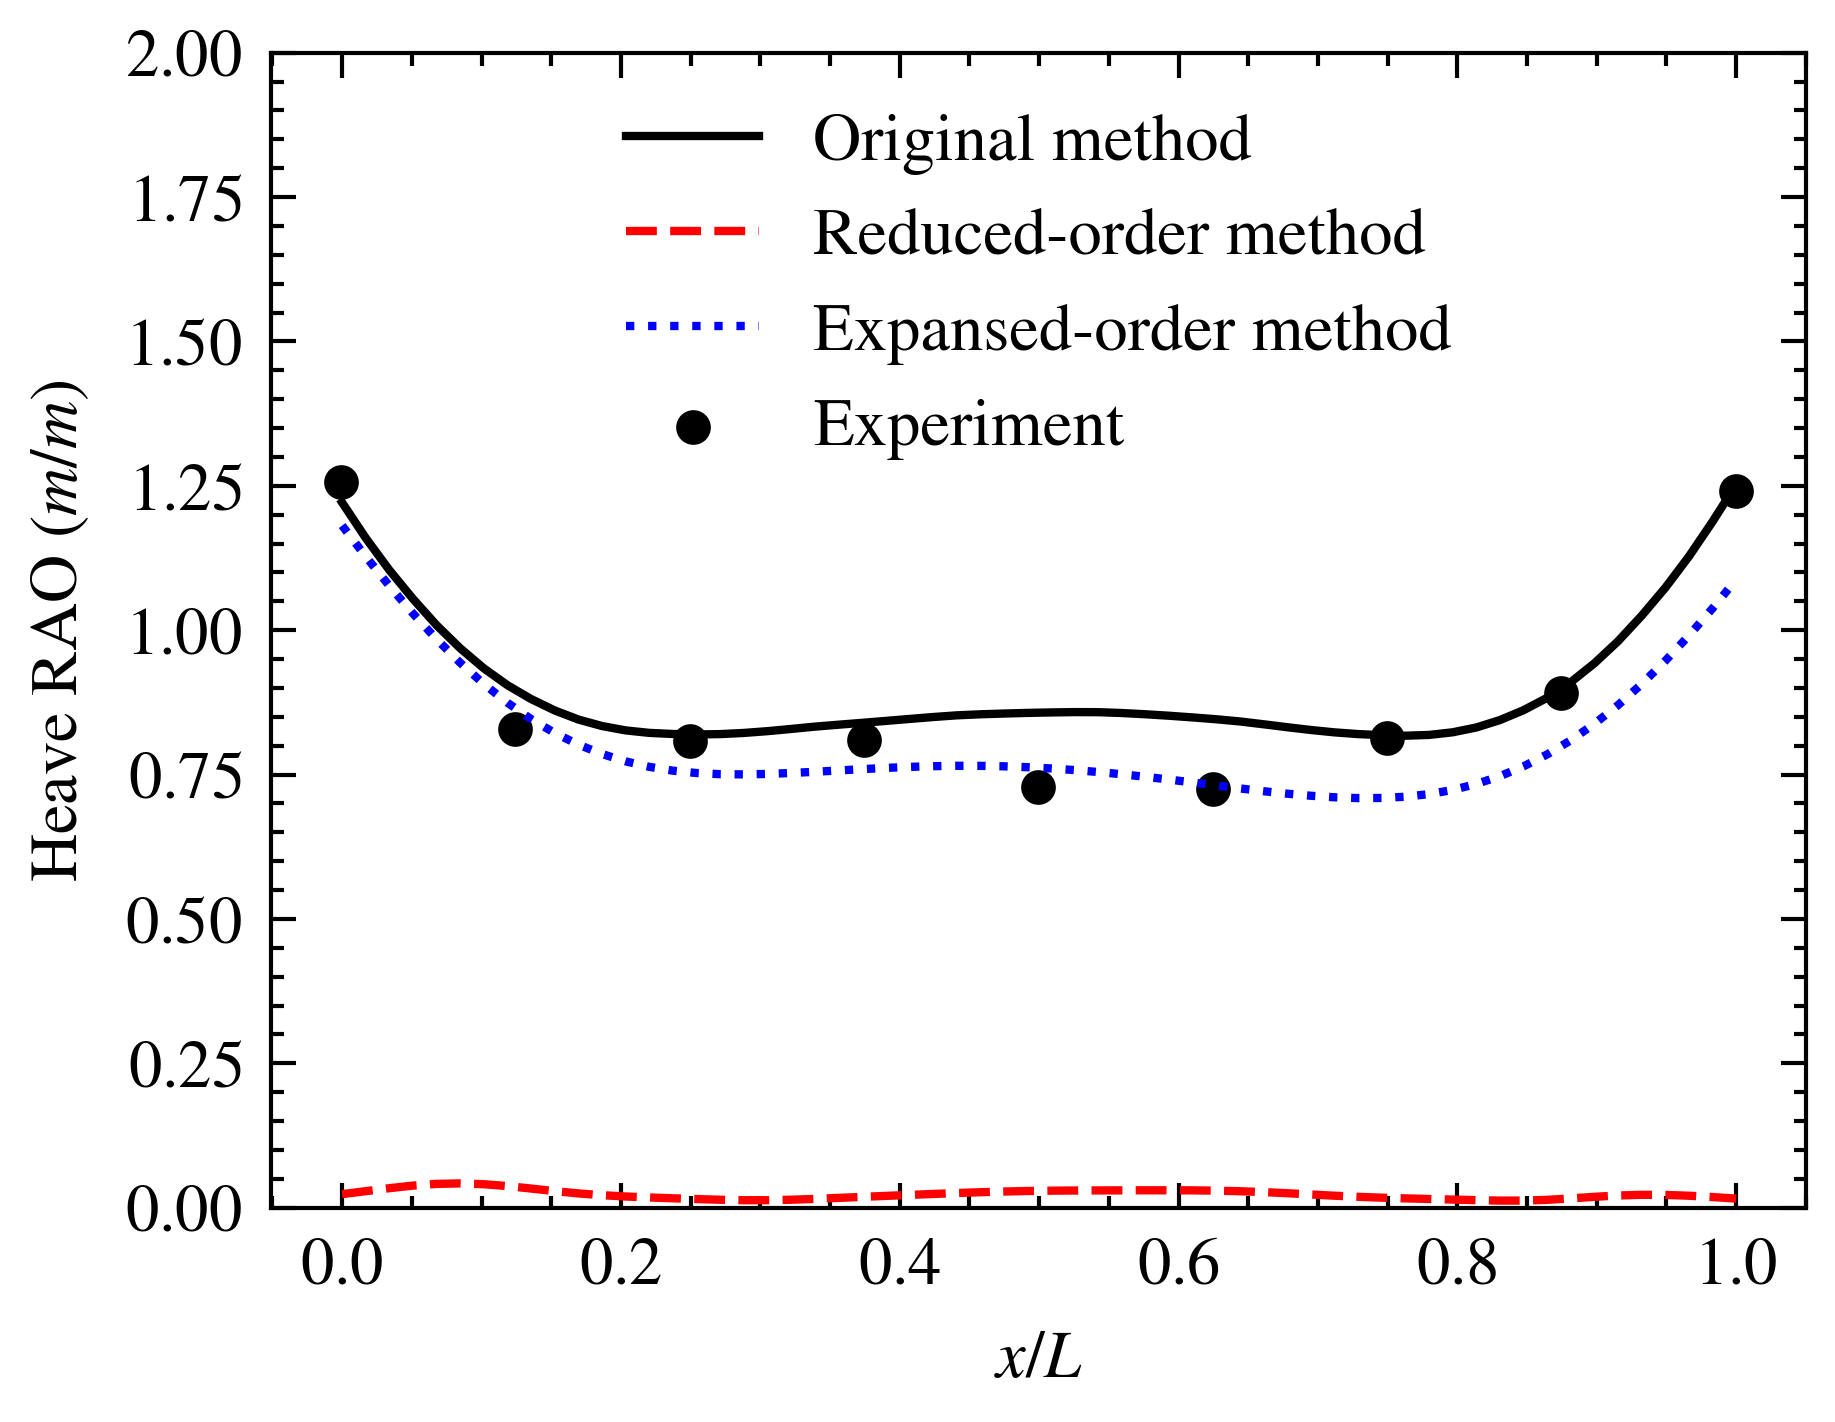

In [7]:
# 老方法、reduce method, expansion method 与实验结果的对比

mid_reduce= global_displacement[367*5-5:427*5-5,:]
mid_old = displacement_old[367*6-6:427*6-6,:]
mid_expansion = displacement_expansion[367*5-5:427*5-5,:]
heave_reduce = abs(mid_reduce[2::5])
heave_old = abs(mid_old[2::6])
mid_expansion = abs(mid_expansion[2::5])

x_exp, y_exp = process_exp_data(f"E:\phd\Code\DM-FEM2D\data\Experiment_300_60\exp_{number}.txt")
y_exp = np.array(y_exp)
# 绘图
import scienceplots
x_present = np.linspace(0,1,60)
plt.style.use(['science','no-latex','ieee'])
plt.plot(x_present,heave_old[::-1], label="Original method")
plt.plot(x_present,heave_reduce, label="Reduced-order method")
plt.plot(x_present, mid_expansion, label="Expansed-order method")
# plt.plot(x_sim_fu, y_sim_fu, label="Fu et al. (2007)")
plt.scatter(x_exp,y_exp,label="Experiment",s=10)
plt.legend() 
plt.ylim(0,2) # 调整y轴坐标
plt.xlabel(r'$x/L$',)
plt.ylabel(r'Heave RAO ($m$/$m$)')
plt.savefig(f"ReducedAndExpan_{number}.pdf",dpi=600)

In [ ]:
# 对比干、湿模态缩减和试验结果
mid_wet = wet_dispacement[367*5-5:427*5-5,:]
mid_dry = global_displacement[367*5-5:427*5-5,:]
heave_wet = abs(mid_wet[2::5])
heave_dry = abs(mid_dry[2::5])
# 与实验结果进行对比、绘图
x_exp, y_exp = process_exp_data(f"E:\phd\Code\DM-FEM2D\data\Experiment_300_60\exp_{number}.txt")
y_exp = np.array(y_exp)
x_sim_fu, y_sim_fu = process_exp_data(f"E:\phd\Code\DM-FEM2D\data\Experiment_300_60\\fu_sim{number}.txt")
y_sim_fu = np.array(y_sim_fu)
x_present = np.linspace(0,1,60)
import scienceplots
plt.style.use(['science','no-latex','ieee'])
plt.plot(x_sim_fu, y_sim_fu, label="Fu et al. (2007)")
plt.plot(x_present,heave_wet, label="Wet Mode")
plt.plot(x_present,heave_dry, label="Dry Mode")
plt.scatter(x_exp,y_exp,label="Model test",s=10)
plt.legend()
plt.ylim(0,1.5) # 调整y轴坐标
plt.xlabel(r'$x/L$',)
plt.ylabel(r'Heave RAO ($m$/$m$)')
plt.savefig(f"wetAndDry_{number}.pdf",dpi=600)


### 5.执行beta = 0 ,0.25 ,0.5, 0.75,1  + 10节点惯性

In [ ]:
### 5.执行beta = 0 ,0.25 ,0.5, 0.75,1  + 10节点惯性
def study_beta_effect(beta,number,stiffness_num):
    """
    Study the effect of the beta parameter in the transformation of the mass matrix.

    Parameters:
    beta (float): The beta parameter value for the mass matrix transformation.

    Returns:
    ndarray: Global displacement array.
    """
    
    num_nodes = 793
    master_nodes = DM_A.calculate_node_positions(424, 6, 10)
    dataset_path = f"E:\phd\Code\DM-FEM2D\HydrodynamicData\Yoga\DM10_{number}_direction0.nc"
    file_m = f'E:\phd\Code\DM-FEM2D\StructureData\Stiffness\JobMesh5_5_S1e-{stiffness_num}_MASS1.mtx'
    file_k = f'E:\phd\Code\DM-FEM2D\StructureData\Stiffness\JobMesh5_5_S1e-{stiffness_num}_STIF1.mtx'

    # Load dataset and other initializations
    dataset = merge_complex_values(xr.open_dataset(dataset_path))
    omega = dataset.omega.values
    M = dm_r.get_stiffness_matrix(file_m)
    k = dm_r.get_stiffness_matrix(file_k)

    # Reduce degrees of freedom (DOFs)
    M_consistant = SEREP.reduce_dofs(M, num_nodes, [5])
    k = SEREP.reduce_dofs(k, num_nodes, [5])

    # Transform mass matrix with the specified beta value
    M = SEREP.transform_mass_matrix(M_consistant, beta=beta)

    # Obtain master and slave DOFs
    MasterDofs, SlaveDofs = SEREP.separate_dofs(num_nodes, master_nodes)

    # Reduce matrix using SEREP
    MR, KR, T = SEREP.SEREP(k, M, SlaveDofs, master_nodes)

    # Hydrodynamic data processing
    added_mass = dataset['added_mass'][0].values
    radiation_damping = dataset['radiation_damping'][0].values
    inertia_matrix = dataset['inertia_matrix'].values
    F_w = dataset['Froude_Krylov_force'][0].values + dataset['diffraction_force'][0].values
    hydrostatic_stiffness = dataset['hydrostatic_stiffness'].values

    # Reduce the matrices
    added_mass = SEREP.reduce_dofs(added_mass, 10, [5])
    radiation_damping = SEREP.reduce_dofs(radiation_damping, 10, [5])
    hydrostatic_stiffness = SEREP.reduce_dofs(hydrostatic_stiffness, 10, [5])
    inertia_matrix = SEREP.reduce_dofs(inertia_matrix, 10, [5])
    F_w = SEREP.reduce_force_matrix_dofs(F_w, 10, 5).reshape(1, 50)

    # Generate the system matrices
    mass = added_mass + MR
    damping = radiation_damping
    stiffness = hydrostatic_stiffness + KR

    # Solve in frequency domain
    master_displacement = DM_A.solve_frequency_domain(mass, damping, stiffness, F_w, omega)

    # Restore and reorder global displacement
    global_displacement_disorder = T @ master_displacement
    global_displacement = SEREP.reorder_displacement_matrix(global_displacement_disorder, MasterDofs, SlaveDofs)

    return global_displacement


In [ ]:
number = 60
stiffness_num = 7
d0=study_beta_effect(0,number,stiffness_num)
# d025=study_beta_effect(0.25)
d05=study_beta_effect(0.5,number,stiffness_num)
# d075=study_beta_effect(0.75)
d1=study_beta_effect(1,number,stiffness_num)

In [ ]:
num_nodes = 793
master_nodes = DM_A.calculate_node_positions(424, 6, 10)
dataset_path = f"E:\phd\Code\DM-FEM2D\HydrodynamicData\Yoga\DM10_{number}_direction0.nc"
file_m = f'E:\phd\Code\DM-FEM2D\StructureData\Stiffness\JobMesh5_5_S1e-{stiffness_num}_MASS1.mtx'
file_k = f'E:\phd\Code\DM-FEM2D\StructureData\Stiffness\JobMesh5_5_S1e-{stiffness_num}_STIF1.mtx'

# Load dataset and other initializations
dataset = merge_complex_values(xr.open_dataset(dataset_path))
omega = dataset.omega.values
M = dm_r.get_stiffness_matrix(file_m)
k = dm_r.get_stiffness_matrix(file_k)

# Reduce degrees of freedom (DOFs)
M_consistant = SEREP.reduce_dofs(M, num_nodes, [5])
k = SEREP.reduce_dofs(k, num_nodes, [5])

# Transform mass matrix with the specified beta value
M = SEREP.transform_mass_matrix(M_consistant, beta=0)

# Obtain master and slave DOFs
MasterDofs, SlaveDofs = SEREP.separate_dofs(num_nodes, master_nodes)

# Reduce matrix using SEREP
MR, KR, T = SEREP.SEREP(k, M, SlaveDofs, master_nodes)

# Hydrodynamic data processing
added_mass = dataset['added_mass'][0].values
radiation_damping = dataset['radiation_damping'][0].values
inertia_matrix = dataset['inertia_matrix'].values
F_w = dataset['Froude_Krylov_force'][0].values + dataset['diffraction_force'][0].values
hydrostatic_stiffness = dataset['hydrostatic_stiffness'].values

# Reduce the matrices
added_mass = SEREP.reduce_dofs(added_mass, 10, [5])
radiation_damping = SEREP.reduce_dofs(radiation_damping, 10, [5])
hydrostatic_stiffness = SEREP.reduce_dofs(hydrostatic_stiffness, 10, [5])
inertia_matrix = SEREP.reduce_dofs(inertia_matrix, 10, [5])
F_w = SEREP.reduce_force_matrix_dofs(F_w, 10, 5).reshape(1, 50)

# Generate the system matrices
mass = added_mass + inertia_matrix
damping = radiation_damping
stiffness = hydrostatic_stiffness + KR

# Solve in frequency domain
master_displacement = DM_A.solve_frequency_domain(mass, damping, stiffness, F_w, omega)

# Restore and reorder global displacement
global_displacement_disorder = T @ master_displacement
global_displacement = SEREP.reorder_displacement_matrix(global_displacement_disorder, MasterDofs, SlaveDofs)

In [ ]:
#绘图
mid0 = d0[367*5-5:427*5-5,:]
mid025 = d025[367*5-5:427*5-5,:]
mid05 = d05[367*5-5:427*5-5,:]
mid075 = d075[367*5-5:427*5-5,:]
mid1 = d1[367*5-5:427*5-5,:]
mid = global_displacement[367*5-5:427*5-5,:]
heave0 = abs(mid0[2::5])
heave025 = abs(mid025[2::5])
heave05 = abs(mid05[2::5])
heave075 = abs(mid075[2::5])
heave1 = abs(mid1[2::5])
heave = abs(mid[2::5])
# 与实验结果进行对比、绘图
x_exp, y_exp = process_exp_data("E:\phd\Code\DM-FEM2D\data\Experiment_300_60\exp_60.txt")
y_exp = np.array(y_exp)
x_present = np.linspace(0,1,60)
import scienceplots
plt.style.use(['science','no-latex','ieee'])
plt.plot(x_present,heave0, label=r"$\beta$ = 0")
plt.plot(x_present,heave025, label=r"$\beta$ = 0.25")
plt.plot(x_present,heave05, label=r"$\beta$ = 0.5")
plt.plot(x_present,heave075, label=r"$\beta$ = 0.75")
plt.plot(x_present,heave1, label=r"$\beta$ = 1")
plt.plot(x_present,heave, label="Original Method")
plt.scatter(x_exp,y_exp,label="Model test",s=10)
plt.legend()
plt.ylim(0,2) # 调整y轴坐标
plt.xlabel(r'$x/L$',)
plt.ylabel(r'Heave RAO ($m$/$m$)')
# plt.savefig("E:\phd\Code\DM-FEM2D\figures\Beta_effect.png",dpi=300)

In [ ]:
import scienceplots
plt.style.use(['science','no-latex','ieee'])
x_present = np.linspace(0,1,60)
mid0 = d0[367*5-5:427*5-5,:]
mid05 = d05[367*5-5:427*5-5,:]
mid1 = d1[367*5-5:427*5-5,:]
mid = global_displacement[367*5-5:427*5-5,:]
heave0 = abs(mid0[2::5])
heave05 = abs(mid05[2::5])
heave1 = abs(mid1[2::5])
heave = abs(mid[2::5])
# 与实验结果进行对比、绘图
plt.plot(x_present,heave0, label=r"$\beta$ = 0")
plt.plot(x_present,heave, label="Traditional mass matrix")
plt.plot(x_present,heave05, label=r"$\beta$ = 0.5")
plt.plot(x_present,heave1, label=r"$\beta$ = 1")

plt.legend()
plt.ylim(0,2) # 调整y轴坐标
plt.xlabel(r'$x/L$',)
plt.ylabel(r'Heave RAO ($m$/$m$)')
plt.savefig(f"MassMatrix_{number}_{stiffness_num}.pdf",dpi=600)

### 6.对比Fu et al.论文中的数值结果，点p1的结果，频率0.1-2.0

In [ ]:
### 6.对比Fu et al.论文中的数值结果，点p1的结果，频率0.1-2.0
# 执行干模态进行缩减
# define parameters
num_nodes = 793 # 63 793
master_nodes = DM_A.calculate_node_positions(424,6,10) #[41, 39, 37, 35, 33, 31, 29, 27, 25, 23] DM_A.calculate_node_positions(425,6,10)
dataset = merge_complex_values(xr.open_dataset("E:\phd\Code\DM-FEM2D\HydrodynamicData\Yoga\BM10_direaction0_full.nc"))
omega = dataset.omega.values
Area = 5*5
nodes_per_row = 61
# read mass and stiffness matrix
file_m = 'E:\phd\Code\DM-FEM2D\StructureData\JobMesh5_5_MASS1.mtx'
file_k = 'E:\phd\Code\DM-FEM2D\StructureData\JobMesh5_5_STIF1.mtx' 
M = dm_r.get_stiffness_matrix(file_m)
k = dm_r.get_stiffness_matrix(file_k)

# reduce dofs
M_consistant= SEREP.reduce_dofs(M, num_nodes, [5])
k = SEREP.reduce_dofs(k, num_nodes, [5])

# transform mass matrix, beta=0 is consistant mass matrix
M = SEREP.transform_mass_matrix(M_consistant,beta=0)
# obtaine master dofs and slave dofs
MasterDofs, SlaveDofs = SEREP.separate_dofs(num_nodes, master_nodes)

# reduce matrix use SEREP
MR,KR,T = SEREP.SEREP(k, M, SlaveDofs, master_nodes)
# node displacement
displacement_node = []
global_mean_dispacement = []
for i in range(len(omega)):

    # read hydrodynamic data
    added_mass = dataset['added_mass'][i].values
    radiation_damping = dataset['radiation_damping'][i].values
    inertia_matrix = dataset['inertia_matrix'].values
    # hydrostatic_stiffness = dataset['hydrostatic_stiffness'].values
    F_w = dataset['Froude_Krylov_force'][i].values + dataset['diffraction_force'][i].values
    # REDUCE THE MATRICES
    added_mass = SEREP.reduce_dofs(added_mass,10,[5])
    radiation_damping = SEREP.reduce_dofs(radiation_damping,10,[5])
    # hyrostatic stiffness or fem spring stiffness
    # 1. choice hydrostatic stiffness
    hydrostatic_stiffness = dataset['hydrostatic_stiffness'].values
    hydrostatic_stiffness = SEREP.reduce_dofs(hydrostatic_stiffness,10,[5])
    # 2. choice fem spring stiffness
    # hydrostatic_stiffness = SEREP.get_fem_spring_stiffness(num_nodes, nodes_per_row, Area)
    # hydrostatic_stiffness = SEREP.reduce_dofs(hydrostatic_stiffness,num_nodes,[5])
    # hydrostatic_stiffness = T.T @ hydrostatic_stiffness @ T

    inertia_matrix = SEREP.reduce_dofs(inertia_matrix,10,[5])
    F_w = SEREP.reduce_force_matrix_dofs(F_w, 10, 5).reshape(1,50)
    # F_w = F_w.reshape(10,5)[::-1].reshape(1,50)
    # Generate the system matrices
    mass = added_mass + MR
    damping = radiation_damping
    stiffness =  hydrostatic_stiffness + KR
    # Solve in frequency domain
    master_displacement = DM_A.solve_frequency_domain(mass, damping, stiffness, F_w, omega[i])
    # Restore global displacement under disorder masterdofs and slavedofs
    global_displacement_disorder = T @ master_displacement
    # Reorder global displacement under order
    global_displacement = SEREP.reorder_displacement_matrix(global_displacement_disorder, MasterDofs, SlaveDofs)
    # print(global_displacement.shape)
    global_displacement = global_displacement.reshape(793,5)
    displacement_node.append(global_displacement[426,2]) # 367 397   P5：427
    global_mean_dispacement.append(abs(np.sum(abs(global_displacement[:,2]))/793))

displacement_node = np.array(displacement_node)
global_mean_dispacement = np.array(global_mean_dispacement)

In [ ]:
# 波长计算
import numpy as np
from scipy.optimize import fsolve

# Constants
g = 9.81  # Gravity acceleration, m/s^2
h = 58.5    # Water depth, meters

# Dispersion relation function
def dispersion_relation(k, omega):
    return omega**2 - g * k * np.tanh(k * h)

# Function to calculate wavelength for a single angular frequency
def calculate_wavelength_for_frequency(omega):
    initial_guess = omega / np.sqrt(g * h)
    k = fsolve(dispersion_relation, initial_guess, args=(omega))[0]
    return 2 * np.pi / k

# # Array of angular frequencies
# angular_frequencies = dataset.omega.values

# # Calculate wavelengths for each angular frequency
# wavelengths = np.array([calculate_wavelength_for_frequency(omega) for omega in angular_frequencies])

# Output wavelengths
# print(wavelengths)


In [ ]:
bochang = dataset.wavelength.values/300

In [ ]:
# 绘制面平均位移响应
plt.plot(bochang,abs(global_mean_dispacement),label="Present")
plt.legend()
plt.ylim(0,1.8) # 调整y轴坐标
plt.title('Mean')
plt.xlabel(r'$\lambda/L$')
plt.ylabel(r'Veritical Displacement')
# plt.grid(True)
plt.show()


In [ ]:
import pandas as pd

# Load the CSV file
file_path = 'E:\phd\Code\DM-FEM2D\FEM_Reduce\Fu2007P1.csv'
data = pd.read_csv(file_path)
import matplotlib.pyplot as plt
import scienceplots
# plt.figure(figsize=(10, 6))
plt.style.use(['science','no-latex','ieee'])

# Adjusting the data to include the first row as part of the dataset
data.loc[-1] = [0.051163211, 0.996357567]  # adding a row
data.index = data.index + 1  # shifting index
data.sort_index(inplace=True)
# Array of angular frequencies
angular_frequencies = data.iloc[:, 0]
# Calculate wavelengths for each angular frequency
wavelengths = np.array([calculate_wavelength_for_frequency(omega) for omega in angular_frequencies])
# Plotting the data
plt.plot(wavelengths[1:]/300, data.iloc[1:, 1],label="Fu et al. (2007)")
plt.plot(bochang,abs(displacement_node),label="Present")
plt.legend()
plt.ylim(0,1.4) # 调整y轴坐标
plt.title('P1')
plt.xlabel(r'$\lambda/L$')
plt.ylabel(r'Veritical Displacement')
# plt.grid(True)
plt.show()



In [ ]:
import pandas as pd

# Load the CSV file
file_path = 'E:\phd\Code\DM-FEM2D\FEM_Reduce\Fu2007P3.csv'
data = pd.read_csv(file_path)
import matplotlib.pyplot as plt
import scienceplots
# plt.figure(figsize=(10, 6))
plt.style.use(['science','no-latex','ieee'])

# Adjusting the data to include the first row as part of the dataset
data.loc[-1] = [0.047330752049542624, 0.9984574681931668]  # adding a row
data.index = data.index + 1  # shifting index
data.sort_index(inplace=True)
angular_frequencies = data.iloc[:, 0]
# Calculate wavelengths for each angular frequency
wavelengths = np.array([calculate_wavelength_for_frequency(omega) for omega in angular_frequencies])
# Plotting the data
plt.plot(wavelengths[1:]/300, data.iloc[1:, 1],label="Fu et al. (2007)")
plt.plot(bochang,abs(displacement_node),label="Present")
plt.legend()
plt.ylim(0,1.4) # 调整y轴坐标
plt.title('P3')
plt.xlabel(r'$\lambda/L$')
plt.ylabel(r'Veritical Displacement')
# plt.grid(True)
plt.show()


In [ ]:
import pandas as pd

# Load the CSV file
file_path = 'E:\phd\Code\DM-FEM2D\FEM_Reduce\Fu2007P1.csv'
data = pd.read_csv(file_path)
import matplotlib.pyplot as plt
import scienceplots
# plt.figure(figsize=(10, 6))
plt.style.use(['science','no-latex','ieee'])

# Adjusting the data to include the first row as part of the dataset
data.loc[-1] = [0.051163211, 0.996357567]  # adding a row
data.index = data.index + 1  # shifting index
data.sort_index(inplace=True)
# Plotting the data
plt.plot(data.iloc[:, 0], data.iloc[:, 1],label="Fu et al. (2007)")
plt.plot(omega,abs(displacement_node),label="Present")

# Drawing vertical lines at specified x values
vertical_lines = [0.156, 0.430, 0.507, 0.845, 1.036, 1.398, 1.604, 2.0]
for vl in vertical_lines:
    plt.axvline(x=vl, color='b', linestyle='--')

plt.legend()
plt.ylim(0,1.4) # 调整y轴坐标
plt.title('P1')
plt.xlabel(r'$\lambda/L$')
plt.ylabel(r'Veritical Displacement')
# plt.grid(True)
plt.show()



In [ ]:
import pandas as pd

# Load the CSV file
file_path = 'E:\phd\Code\DM-FEM2D\FEM_Reduce\Fu2007P3.csv'
data = pd.read_csv(file_path)
import matplotlib.pyplot as plt
import scienceplots
# plt.figure(figsize=(10, 6))
plt.style.use(['science','no-latex','ieee'])

# Adjusting the data to include the first row as part of the dataset
data.loc[-1] = [0.047330752049542624, 0.9984574681931668]  # adding a row
data.index = data.index + 1  # shifting index
data.sort_index(inplace=True)
# Plotting the data
plt.plot(data.iloc[:,0], data.iloc[:, 1],label="Fu et al. (2007)")
plt.plot(omega,abs(displacement_node),label="Present")

# Drawing vertical lines at specified x values
vertical_lines = [0.156, 0.430, 0.507, 0.845, 1.036, 1.398, 1.604, 2.0]
for vl in vertical_lines:
    plt.axvline(x=vl, color='b', linestyle='--')

plt.legend()
plt.ylim(0,1.4) # 调整y轴坐标
plt.title('P3')
plt.xlabel(r'$\lambda/L$')
plt.ylabel(r'Veritical Displacement')
# plt.grid(True)
plt.show()


## 7、对比S4\S4R5\S4R三个单元的区别

In [ ]:
# 执行S4\S4R5\S4R

def perform_structural_analysis(file_m, file_k):
    """
    Perform structural analysis using modal reduction and return the global displacement.

    :param file_m: File path for the mass matrix.
    :param file_k: File path for the stiffness matrix.
    :return: The global displacement matrix.
    """
    # Define parameters
    num_nodes = 793
    master_nodes = DM_A.calculate_node_positions(424,6,10)
    dataset = merge_complex_values(xr.open_dataset("E:\phd\Code\DM-FEM2D\HydrodynamicData\Yoga\DM10_120_direction0.nc"))
    omega = dataset.omega.values

    # Read mass and stiffness matrix
    M = dm_r.get_stiffness_matrix(file_m)
    k = dm_r.get_stiffness_matrix(file_k)

    # Reduce DOFs
    M_consistant = SEREP.reduce_dofs(M, num_nodes, [5])
    k = SEREP.reduce_dofs(k, num_nodes, [5])

    # Transform mass matrix, beta=0 is consistant mass matrix
    M = SEREP.transform_mass_matrix(M_consistant, beta=0)

    # Obtain master and slave DOFs
    MasterDofs, SlaveDofs = SEREP.separate_dofs(num_nodes, master_nodes)

    # Reduce matrix using SEREP
    MR, KR, T = SEREP.SEREP(k, M, SlaveDofs, master_nodes)

    # Read and reduce hydrodynamic data
    added_mass = dataset['added_mass'][0].values
    radiation_damping = dataset['radiation_damping'][0].values
    inertia_matrix = dataset['inertia_matrix'].values
    F_w = dataset['Froude_Krylov_force'][0].values + dataset['diffraction_force'][0].values

    added_mass = SEREP.reduce_dofs(added_mass, 10, [5])
    radiation_damping = SEREP.reduce_dofs(radiation_damping, 10, [5])
    hydrostatic_stiffness = dataset['hydrostatic_stiffness'].values
    hydrostatic_stiffness = SEREP.reduce_dofs(hydrostatic_stiffness, 10, [5])
    inertia_matrix = SEREP.reduce_dofs(inertia_matrix, 10, [5])
    F_w = SEREP.reduce_force_matrix_dofs(F_w, 10, 5).reshape(1, 50)

    # Generate system matrices
    mass = added_mass + MR
    damping = radiation_damping
    stiffness = hydrostatic_stiffness + KR

    # Solve in frequency domain
    master_displacement = DM_A.solve_frequency_domain(mass, damping, stiffness, F_w, omega)
    global_displacement_disorder = T @ master_displacement
    # Reorder global displacement under order
    global_displacement = SEREP.reorder_displacement_matrix(global_displacement_disorder, MasterDofs, SlaveDofs)

    return global_displacement


# 执行S4\S4R5\S4R

def perform_structural_analysis_NOREDUCCdof(file_m, file_k):
    """
    Perform structural analysis using modal reduction and return the global displacement.

    :param file_m: File path for the mass matrix.
    :param file_k: File path for the stiffness matrix.
    :return: The global displacement matrix.
    """
    # Define parameters
    num_nodes = 793
    master_nodes = DM_A.calculate_node_positions(424,6,10)
    dataset = merge_complex_values(xr.open_dataset("E:\phd\Code\DM-FEM2D\HydrodynamicData\Yoga\DM10_120_direction0.nc"))
    omega = dataset.omega.values

    # Read mass and stiffness matrix
    M = dm_r.get_stiffness_matrix(file_m)
    k = dm_r.get_stiffness_matrix(file_k)

    # Reduce DOFs
    # M_consistant = SEREP.reduce_dofs(M, num_nodes, [5])
    # k = SEREP.reduce_dofs(k, num_nodes, [5])

    # Transform mass matrix, beta=0 is consistant mass matrix
    # M = SEREP.transform_mass_matrix(M_consistant, beta=0)

    # Obtain master and slave DOFs
    MasterDofs, SlaveDofs = SEREP.separate_dofs(num_nodes, master_nodes)

    # Reduce matrix using SEREP
    MR, KR, T = SEREP.SEREP(k, M, SlaveDofs, master_nodes)

    # Read and reduce hydrodynamic data
    added_mass = dataset['added_mass'][0].values
    radiation_damping = dataset['radiation_damping'][0].values
    inertia_matrix = dataset['inertia_matrix'].values
    F_w = dataset['Froude_Krylov_force'][0].values + dataset['diffraction_force'][0].values

    added_mass = SEREP.reduce_dofs(added_mass, 10, [5])
    radiation_damping = SEREP.reduce_dofs(radiation_damping, 10, [5])
    hydrostatic_stiffness = dataset['hydrostatic_stiffness'].values
    hydrostatic_stiffness = SEREP.reduce_dofs(hydrostatic_stiffness, 10, [5])
    inertia_matrix = SEREP.reduce_dofs(inertia_matrix, 10, [5])
    F_w = SEREP.reduce_force_matrix_dofs(F_w, 10, 5).reshape(1, 50)

    # Generate system matrices
    mass = added_mass + MR
    damping = radiation_damping
    stiffness = hydrostatic_stiffness + KR

    # Solve in frequency domain
    master_displacement = DM_A.solve_frequency_domain(mass, damping, stiffness, F_w, omega)
    global_displacement_disorder = T @ master_displacement
    # Reorder global displacement under order
    global_displacement = SEREP.reorder_displacement_matrix(global_displacement_disorder, MasterDofs, SlaveDofs)

    return global_displacement



In [ ]:
File_m_S4 = 'E:\phd\Code\DM-FEM2D\StructureData\JobMesh5_5_S4_MASS1.mtx'
File_k_S4 = 'E:\phd\Code\DM-FEM2D\StructureData\JobMesh5_5_S4_STIF1.mtx'
File_m_S4R5 = 'E:\phd\Code\DM-FEM2D\StructureData\JobMesh5_5_S4R5_MASS1.mtx'
File_k_S4R5 = 'E:\phd\Code\DM-FEM2D\StructureData\JobMesh5_5_S4R5_STIF1.mtx'
File_m_S4R = 'E:\phd\Code\DM-FEM2D\StructureData\JobMesh5_5_MASS1.mtx'
File_k_S4R = 'E:\phd\Code\DM-FEM2D\StructureData\JobMesh5_5_STIF1.mtx'
Xs4 = perform_structural_analysis(File_m_S4,File_k_S4)

In [ ]:
Xs4r = perform_structural_analysis(File_m_S4R,File_k_S4R)

In [ ]:
# 老方法、reduce method, expansion method 与实验结果的对比

mid_reduce= Xs4[367*5-5:427*5-5,:]
mid_old = Xs4r[367*5-5:427*5-5,:]
# mid_expansion = displacement_expansion[367*5-5:427*5-5,:]
heave_reduce = abs(mid_reduce[2::5])
heave_old = abs(mid_old[2::5])
# mid_expansion = abs(mid_expansion[2::5])

x_exp, y_exp = process_exp_data("E:\phd\Code\DM-FEM2D\data\Experiment_300_60\exp_120.txt")
y_exp = np.array(y_exp)
# 绘图
import scienceplots
x_present = np.linspace(0,1,60)
plt.style.use(['science','no-latex','ieee'])
plt.plot(x_present,heave_old, label="S4R")
plt.plot(x_present,heave_reduce, label="S4")
# plt.plot(x_sim_fu, y_sim_fu, label="Fu et al. (2007)")
plt.scatter(x_exp,y_exp,label="Model test",s=10)
plt.legend() 
plt.ylim(0,1.5) # 调整y轴坐标
plt.xlabel(r'$x/L$',)
plt.ylabel(r'Heave RAO ($m$/$m$)')